# Fusou Datasets - サンプルノートブック

このノートブックでは `fusou-datasets` ライブラリの全機能をデモンストレーションします。

## 1. セットアップ

In [95]:
# ライブラリのインストール（必要な場合）
# !pip install fusou-datasets pandas matplotlib seaborn
!pip install -e ../python

# 日本語フォント対応パッケージのインストール
!pip install japanize-matplotlib

Obtaining file:///home/ogu-h/Documents/GitHub/FUSOU/packages/fusou-datasets/python
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fusou-datasets (pyproject.toml) ... done
  Created wheel for fusou-datasets: filename=fusou_datasets-0.1.1-0.editable-py3-none-any.whl size=4320 sha256=1e528400d068cf74e754c2867a46aabe8308f31b07ba04503af27dc101107cca
  Stored in directory: /tmp/pip-ephem-wheel-cache-3kwwip7b/wheels/fb/4e/bd/52023af5726e156904620ecd6387dae76606f79d6df2880e70
Successfully built fusou-datasets
  Attempting uninstall: fusou-datasets
    Found existing installation: fusou-datasets 0.1.1
    Uninstalling fusou-datasets-0.1.1:
      Successfully uninstalled fusou-datasets-0.1.1


In [96]:
%matplotlib inline

import fusou_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語フォント設定
import matplotlib
matplotlib.rcParams.update({
    'font.sans-serif': ['Noto Sans CJK JP', 'IPAGothic'],
    'axes.unicode_minus': False,
})

sns.set_theme(style='whitegrid')

## 2. ヘルプ表示

In [98]:
# 使い方一覧を表示
fusou_datasets.help()


Fusou Datasets v0.1.1 - Usage Guide

🔧 SETUP
--------------------------------------------------------------------------------
  fusou_datasets.save_api_key("your_api_key")
      Save API key for persistent use.
      Get your key at: https://fusou.dev/dashboard/api-keys

  fusou_datasets.configure(api_key="...", cache_dir="~/.fusou_datasets/cache")
      Configure API credentials and caching.

📋 LIST DATA
--------------------------------------------------------------------------------
  fusou_datasets.list_tables()
      List all available tables. Returns: List[str]

  fusou_datasets.list_period_tags()
      List available period tags. Returns: Dict

📊 LOAD DATA
--------------------------------------------------------------------------------
  df = fusou_datasets.load("table_name")
      Load table data as pandas DataFrame.
      
  df = fusou_datasets.load("table_name", period_tag="2024-01")
      Load specific period's data.

💾 CACHING (requires cache_dir configuration)
------------

## 3. API設定

In [ ]:
# APIキーを保存（初回のみ必要）
fusou_datasets.save_api_key("<your-api-key>")

# キャッシュディレクトリを設定
fusou_datasets.configure(cache_dir="~/.fusou_datasets/cache", api_url="https://r2-parquet.fusou.pages.dev/api/data-loader")

# デバイスIDを確認
print(f"Client ID: {fusou_datasets.get_client_id()}")

Client ID: cbf10829-569e-49da-95f9-e90ce3eb7fec


## 4. テーブル一覧・期間タグ確認

In [100]:
# 利用可能なテーブル一覧
tables = fusou_datasets.list_tables()
print(f"利用可能テーブル数: {len(tables)}")
for t in tables:
    print(f"  - {t}")

利用可能テーブル数: 28
  - battle
  - cells
  - closing_raigeki
  - enemy_deck
  - enemy_ship
  - enemy_slotitem
  - env_info
  - hougeki
  - hougeki_list
  - opening_airattack
  - opening_airattack_list
  - opening_raigeki
  - own_deck
  - own_ship
  - own_slotitem
  - mst_equip_exslot
  - mst_equip_exslot_ship
  - mst_equip_limit_exslot
  - mst_equip_ship
  - mst_map_area
  - mst_map_info
  - mst_payitem
  - mst_ship
  - mst_ship_upgrade
  - mst_shipgraph
  - mst_slotitem
  - mst_slotitem_equiptype
  - mst_stype


In [101]:
# 利用可能な期間タグ
period_info = fusou_datasets.list_period_tags()
print(f"最新期間: {period_info.get('latest')}")
print(f"全期間: {period_info.get('period_tags')}")

最新期間: 2025-12-27
全期間: ['2025-12-27', '2025-12-18', '2025-11-05', '2025-10-29', '2025-10-16', '2025-09-26', '2025-08-27', '2025-07-26', '2025-06-27', '2025-05-30', '2025-05-12', '2025-04-23', '2025-03-07']


## 5. データロード

In [102]:
# 基本的なロード（最新データ）
df = fusou_datasets.load(
    "battle",
    period_tag="latest",
    force_download=True,
)
print(f"battle: {len(df)} 行")
df.head()

Loading battle: 100%|██████████| 2/2 [00:01<00:00,  1.78file/s]

battle: 6 行



[Cache] Saved battle to cache (6 records)


,env_uuid,uuid,index,battle_order,timestamp,midnight_timestamp,cell_id,f_deck_id,e_deck_id,friend_deck_id,...,opening_taisen,opening_raigeki,hougeki,closing_raigeki,friendly_force_attack,midnight_hougeki,f_nowhps,e_nowhps,midnight_f_nowhps,midnight_e_nowhps
0,019bcc15-c368-7003-a090-3a8143a7c9df,019bcc15-c368-7003-a090-3a83ceae4ce1,0,"[8, 16, 24, 32, 40, 48, 56, 64, 65, 72]",1768655478,None,3,019bcc15-c368-7003-a090-3a8e183906bb,019bcc15-c368-7003-a090-3a85335a7d63,None,...,None,019bcc15-c368-7003-a090-3a8a39b9cc76,019bcc15-c368-7003-a090-3a828e000a68,019bcc15-c368-7003-a090-3a81378ffcc0,None,None,"[39, 15]","[33, 20, 20]",None,None
1,019bcc15-c368-7003-a090-3a8143a7c9df,019bcc15-c368-7003-a090-3a83ceae4ce1,1,"[8, 16, 24, 32, 40, 48, 56, 64, 65, 72]",1768655421,None,1,019bcc15-c368-7003-a090-3a8d175c8102,019bcc15-c368-7003-a090-3a8781ef5843,None,...,None,019bcc15-c368-7003-a090-3a84c670dc5a,None,None,None,None,"[39, 15]",[24],None,None
2,019baf2f-8a18-7002-8bbe-7f68ee03afb0,019baf2f-8a18-7002-8bbe-7f602e440cce,0,"[8, 16, 24, 32, 40, 48, 56, 64, 65, 72]",1768170617,None,3,019baf2f-8a18-7002-8bbe-7f656c6b662d,019baf2f-8a18-7002-8bbe-7f6badbe2432,None,...,None,019baf2f-8a18-7002-8bbe-7f684b0598f7,019baf2f-8a18-7002-8bbe-7f6d2fdb29d2,019baf2f-8a18-7002-8bbe-7f6d5b6d02de,None,None,"[39, 15]","[33, 20, 20]",None,None
3,019baf2f-8a18-7002-8bbe-7f68ee03afb0,019baf2f-8a18-7002-8bbe-7f602e440cce,1,"[8, 16, 24, 32, 40, 48, 56, 64, 65, 72]",1768170560,None,1,019baf2f-8a18-7002-8bbe-7f6dbf32039b,019baf2f-8a18-7002-8bbe-7f68e00e254c,None,...,None,019baf2f-8a18-7002-8bbe-7f62c74b792f,None,None,None,None,"[39, 15]",[22],None,None
4,019baf32-8ba0-7002-90d7-add5258d20ef,019baf32-8ba0-7002-90d7-add04ed8eed3,0,"[8, 16, 24, 32, 40, 48, 56, 64, 65, 72]",1768170774,None,1,019baf32-8ba0-7002-90d7-addf03e8b4c5,019baf32-8ba0-7002-90d7-add459cfbfd3,None,...,None,019baf32-8ba0-7002-90d7-addff70d3d60,None,None,None,None,"[39, 16]",[22],None,None


In [103]:
# 特定の期間タグを指定
# df_ship_202401 = fusou_datasets.load("mst_ship", period_tag="2024-01")

In [104]:
# キャッシュからのロード（オフラインモード - 2回目以降高速）
df_ship_cached = fusou_datasets.load("battle", offline=True)
print(f"キャッシュからロード: {len(df_ship_cached)} 行")

キャッシュからロード: 6 行


[Cache] Loading battle from cache (offline)


## 6. クエリエンジン（テーブル結合）

In [105]:
from fusou_datasets import Tables, query

# 利用可能なテーブルスキーマを確認
print("Tables.Battle のカラム例:")
print(f"  - TABLE: {Tables.Battle.TABLE}")
print(f"  - TIMESTAMP: {Tables.Battle.TIMESTAMP}")
print(f"  - F_DECK_ID: {Tables.Battle.F_DECK_ID}")

Tables.Battle のカラム例:
  - TABLE: battle
  - TIMESTAMP: timestamp
  - F_DECK_ID: f_deck_id


In [106]:
# クエリに必要なテーブルをロード
fusou_datasets.load("battle")
fusou_datasets.load("own_deck")

[Cache] Loading battle from cache (valid)
[Cache] Loading own_deck from cache (valid)


,env_uuid,uuid,ship_ids,combined_flag
0,019bcc15-c368-7003-a090-3a8143a7c9df,019bcc15-c368-7003-a090-3a8e183906bb,019bcc15-c368-7003-a090-3a8002524a2b,None
1,019bcc15-c368-7003-a090-3a8143a7c9df,019bcc15-c368-7003-a090-3a8d175c8102,019bcc15-c368-7003-a090-3a8f2e62d0e3,None
2,019baf2f-8a18-7002-8bbe-7f68ee03afb0,019baf2f-8a18-7002-8bbe-7f656c6b662d,019baf2f-8a18-7002-8bbe-7f6bb72e18e6,None
3,019baf2f-8a18-7002-8bbe-7f68ee03afb0,019baf2f-8a18-7002-8bbe-7f6dbf32039b,019baf2f-8a18-7002-8bbe-7f620a5161ef,None
4,019baf32-8ba0-7002-90d7-add5258d20ef,019baf32-8ba0-7002-90d7-addf03e8b4c5,019baf32-8ba0-7002-90d7-addd7c12137c,None
5,019baf32-8ba0-7002-90d7-add5258d20ef,019baf32-8ba0-7002-90d7-add918750d19,019baf32-8ba0-7002-90d7-addb8bf97fea,None


In [107]:
# 型安全なクエリ（自動JOIN）
result = query([Tables.Battle.TIMESTAMP, Tables.Battle.F_FORMATION, Tables.OwnDeck.UUID])
print(f"結果: {len(result)} 行")
result.head()

Querying from cache: battle
Joining own_deck on f_deck_id=uuid...
結果: 6 行


,timestamp,f_formation,uuid
0,1768655478,1,019bcc15-c368-7003-a090-3a83ceae4ce1
1,1768655421,1,019bcc15-c368-7003-a090-3a83ceae4ce1
2,1768170617,1,019baf2f-8a18-7002-8bbe-7f602e440cce
3,1768170560,1,019baf2f-8a18-7002-8bbe-7f602e440cce
4,1768170774,1,019baf32-8ba0-7002-90d7-add04ed8eed3


## 7. データ分析サンプル

### 7.1 艦種別の統計

[Cache] Loading mst_ship from cache (valid)


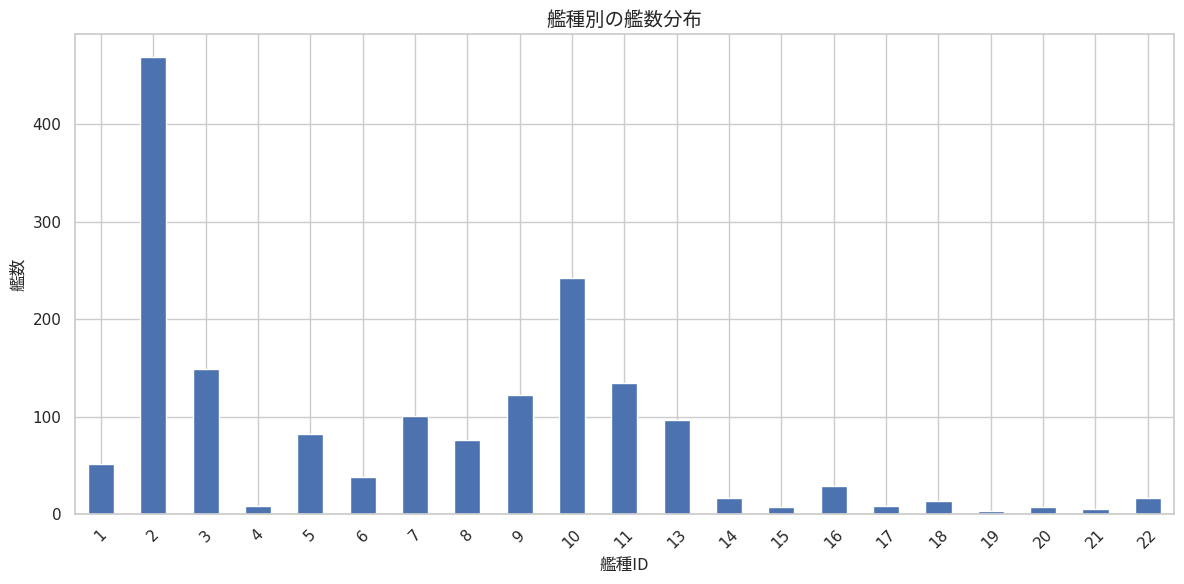

In [108]:
# 艦種別の艦数をカウント
import matplotlib.font_manager as fm
jpfont = fm.FontProperties(fname='/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc', size=11)

df_ship = fusou_datasets.load("mst_ship")

if 'stype' in df_ship.columns:
    ship_type_counts = df_ship['stype'].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ship_type_counts.plot(kind='bar', ax=ax)
    ax.set_title('艦種別の艦数分布', fontproperties=jpfont, fontsize=14, fontweight='bold')
    ax.set_xlabel('艦種ID', fontproperties=jpfont, fontsize=12)
    ax.set_ylabel('艦数', fontproperties=jpfont, fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("'stype' カラムが存在しません")
    print(f"利用可能なカラム: {df_ship.columns.tolist()}")

### 7.2 装備データの分析

In [109]:
# 装備マスタをロード
df_slotitem = fusou_datasets.load("mst_slotitem")
print(f"装備数: {len(df_slotitem)}")
df_slotitem.head()

装備数: 717


[Cache] Loading mst_slotitem from cache (valid)


,id,sortno,name,type,taik,souk,houg,raig,soku,baku,...,luck,leng,rare,taibaku,geigeki,broken,usebull,version,cost,distance
0,57,57,彗星一二型甲,"[3, 5, 7, 7, 16]",0,0,0,0,0,10,...,0,0,2,0,0,"[2, 3, 0, 4]",0,4.0,6.0,5.0
1,179,179,試製61cm六連装(酸素)魚雷,"[2, 3, 5, 5, 0]",0,0,0,14,0,0,...,0,1,4,0,0,"[2, 4, 2, 0]",0,2.0,NaN,NaN
2,171,171,OS2U,"[5, 7, 10, 10, 43]",0,0,0,0,0,1,...,0,0,3,0,0,"[2, 1, 0, 2]",0,2.0,6.0,3.0
3,271,271,紫電改四,"[3, 5, 6, 6, 12]",0,1,0,0,0,0,...,0,0,4,0,0,"[2, 4, 0, 8]",0,NaN,7.0,4.0
4,90,90,20.3cm(2号)連装砲,"[1, 1, 2, 2, 0]",0,0,9,0,0,0,...,0,2,1,0,0,"[0, 3, 4, 0]",0,NaN,NaN,NaN


In [110]:
# 装備種別の分布
if 'type' in df_slotitem.columns:
    # type がリストの場合の処理
    if df_slotitem['type'].dtype == 'object':
        print("装備タイプのサンプル:")
        print(df_slotitem['type'].head())

装備タイプのサンプル:
0      [3, 5, 7, 7, 16]
1       [2, 3, 5, 5, 0]
2    [5, 7, 10, 10, 43]
3      [3, 5, 6, 6, 12]
4       [1, 1, 2, 2, 0]
Name: type, dtype: object


### 7.3 戦闘データの時系列分析

戦闘レコード数: 6
日数: 7


[Cache] Loading battle from cache (offline)


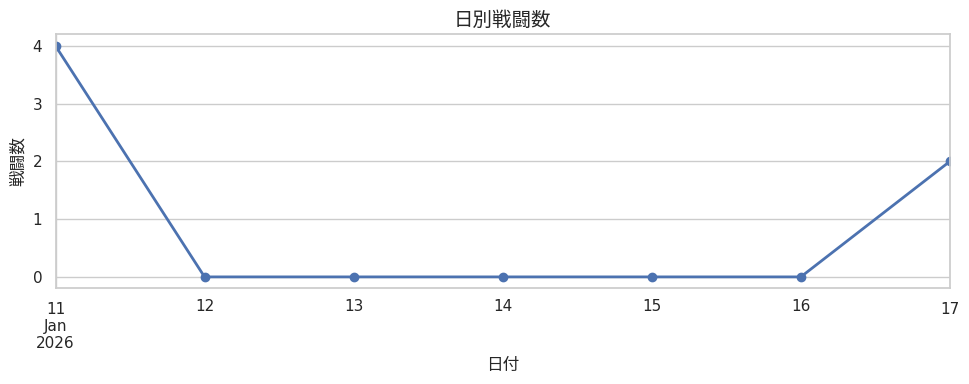

In [118]:
# 戦闘データをロード（キャッシュから）
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pandas.plotting._matplotlib.core')

jpfont = fm.FontProperties(fname='/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc', size=11)

try:
    df_battle = fusou_datasets.load("battle", offline=True)
    print(f"戦闘レコード数: {len(df_battle)}")
    
    if 'timestamp' in df_battle.columns:
        # タイムスタンプをdatetimeに変換
        df_battle['datetime'] = pd.to_datetime(df_battle['timestamp'], unit='s')
        
        # 日別の戦闘数
        daily_battles = df_battle.set_index('datetime').resample('D').size()
        print(f"日数: {len(daily_battles)}")
        
        fig, ax = plt.subplots(figsize=(10, 4))
        daily_battles.plot(ax=ax, linewidth=2, marker='o')
        ax.set_title('日別戦闘数', fontproperties=jpfont, fontsize=14, fontweight='bold')
        ax.set_xlabel('日付', fontproperties=jpfont, fontsize=12)
        ax.set_ylabel('戦闘数', fontproperties=jpfont, fontsize=12)
        
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"戦闘データがキャッシュにありません: {e}")
    print("先に fusou_datasets.load('battle') を実行してください")

## 8. キャッシュ管理

In [112]:
# キャッシュの状態確認（任意）
from pathlib import Path

cache_dir = Path("~/.fusou_datasets/cache").expanduser()
if cache_dir.exists():
    cached_tables = [d.name for d in cache_dir.iterdir() if d.is_dir()]
    print(f"キャッシュされたテーブル: {cached_tables}")
else:
    print("キャッシュディレクトリがありません")

キャッシュされたテーブル: ['own_deck', 'mst_ship', 'battle', 'mst_slotitem']


In [113]:
# 特定テーブルのキャッシュをクリア
# fusou_datasets.clear_cache("mst_ship")

# 全キャッシュをクリア
# fusou_datasets.clear_cache()

## 9. まとめ

| 機能 | コマンド |
|------|----------|
| ヘルプ表示 | `fusou_datasets.help()` |
| テーブル一覧 | `fusou_datasets.list_tables()` |
| データロード | `fusou_datasets.load("table")` |
| オフラインモード | `fusou_datasets.load("table", offline=True)` |
| 強制再ダウンロード | `fusou_datasets.load("table", force_download=True)` |
| クエリ（JOIN） | `query([Tables.X.Y, Tables.Z.W])` |
| キャッシュクリア | `fusou_datasets.clear_cache()` |